# GPT-2 Training Replication Notebook

| Model | Date | Blog | Paper |
|-------|------|------|-------|
| GPT-1 | June 2018 | [Improving Language Understanding with Unsupervised Learning](https://openai.com/index/language-unsupervised/) | [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) |
| GPT-2 | February 2019 | [Better Language Models and Their Implications](https://openai.com/index/better-language-models/) | [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) |
| GPT-3 | May 2020 | [Language Models are Few-Shot Learners](https://openai.com/index/language-models-are-few-shot-learners/) | [Language Models are Few-Shot Learners](https://arxiv.org/pdf/2005.14165) |
| GPT-4 | March 2023 | [GPT-4](https://openai.com/index/gpt-4/) · [GPT-4 Research](https://openai.com/index/gpt-4-research/) | [GPT-4 Technical Report](https://arxiv.org/abs/2303.08774) |
| GPT-5 | August 2025 | [Introducing GPT-5](https://openai.com/index/introducing-gpt-5/) | [GPT-5 Technical Report](https://arxiv.org/abs/2601.03267) |

## 1. AR-LLMs (GPT-2) Generation

- In this jupyter notebook, we will train a GPT-2 model. Before we go, let us see the well-trained GPT-2 from OpenAI and check how to generate new sentences from it. Please figure it by yourself using uv to configure your own env.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore")

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# change it to your local folder if you are not using qz.cfff platform.
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("gpt2") 
# add the EOS token as PAD token to avoid warnings
model = AutoModelForCausalLM.from_pretrained(
    "gpt2", 
    pad_token_id=tokenizer.eos_token_id
).to(device)
print(model) # this gives you the model architecture and parameters.

https://hf-mirror.com
GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [2]:
from torchinfo import summary

print("Generating model summary...")
summary(
    model, 
    input_size=(10, 128), 
    dtypes=[torch.long],  # CRITICAL: GPT-2 expects integers for token IDs, not floats
    device=device,
    col_names=("input_size", "output_size", "num_params", "params_percent")
)

Generating model summary...


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Param %
GPT2LMHeadModel                                    [10, 128]                 --                        --                        -23.67%
├─GPT2Model: 1-1                                   [10, 128]                 --                        --                             --
│    └─Embedding: 2-1                              [10, 128]                 [10, 128, 768]            38,597,376                 23.67%
│    └─Embedding: 2-2                              [1, 128]                  [1, 128, 768]             786,432                     0.48%
│    └─Dropout: 2-3                                [10, 128, 768]            [10, 128, 768]            --                             --
│    └─ModuleList: 2-4                             --                        --                        --                             --
│    │    └─GPT2Block: 3-1               

### 1.1 Greedy Search

In [3]:
# encode context the generation is conditioned on
prompt = 'I enjoy walking with my cute dog'
model_inputs = tokenizer(prompt, return_tensors='pt').to(device)
print(model_inputs)
print(tokenizer.eos_token_id) # <|endoftext|>

# generate 40 new tokens
greedy_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    pad_token_id=tokenizer.eos_token_id
    )
print("Output: " + tokenizer.decode(greedy_output[0], skip_special_tokens=True))

{'input_ids': tensor([[   40,  2883,  6155,   351,   616, 13779,  3290]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}
50256
Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my


**Hugging face use Greedy search by default. The output looks like repeating itself.**

### 1.2 Beam Search

In [4]:
# activate beam search and early_stopping
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)
print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever


**Beam search try to avoid local optima but still, the output looks like repeating itself.**

### 1.3 Beam Search with N-gram

In [5]:
# set no_repeat_ngram_size to 2
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to take a step back and think about what I want to do next. I've always wanted to be a writer, so I thought I'd share my thoughts on how I would go about writing a book about my love of writing. Here are some of my favorite quotes from the book, as well as


**It seems that beam search with n-gram can avoid repeats. You can also generate multiple setencens as follows:**

In [6]:
# set return_num_sequences > 1
beam_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    num_beams=5,
    no_repeat_ngram_size=2,
    num_return_sequences=3,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

# now we have 3 output sequences
print("Output: ")
for i, beam_output in enumerate(beam_outputs):
    print("{}: {}".format(i, tokenizer.decode(beam_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to
--
1: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with her again.

I've been thinking about this for a while now, and I think it's time for me to
--
2: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's a good idea to
--


### 1.4 Pure Sampling (Standard Sampling)

In [7]:
# set seed to reproduce results. Feel free to change the seed though to get different results
from transformers import set_seed
set_seed(17)

# activate sampling and deactivate top_k by setting top_k = 0
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0, # the model is no longer picking the single best word (greedy decoding)
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " +tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog because when I see him I love it, the way his trunk and he's said to always take us out. We joke around and go outside and catch the sunrise.


Favorite episode is seeing


### 1.5 Standard sampling with temprature

By adding `temperature=0.6` while keeping `top_k=0`, you are still allowing the model to sample from the entire token vocabulary, but you are mathematically altering the odds before the die is rolled.  Before a language model outputs probabilities, its final layer produces raw scores called **logits** ($z$). To convert these raw logits into a proper probability distribution that sums to 1, the model passes them through a Softmax function. Temperature ($T$) is a divisor applied directly to those logits *before* the Softmax is calculated: $p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$.

In [8]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog and I like to play with my dog and I like to touch my dog."

His comments came as the council heard that one of the dogs, a dog named Arlene, had been rescued


### 1.6 Top-k Sampling

In [9]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    pad_token_id=tokenizer.eos_token_id
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog in that small cage and sometimes I get asked by my dog to climb up a wall and take a picture. Well, my dog did do this and has really gotten used to it. As long as


### 1.7 Top-k Sampling with temprature

In [10]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but it's too hard to keep my dog. We love to play, and when we can't, we're happy.

There are a lot of ways to make your dog happy –


### 1.8 Top-p (nucleus) sampling

In [11]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_p=0.92,
    top_k=0,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog behind our wall, yes, we were going to have some fun, but it was this knotted mess we were riding, so our kid let us at least have our first day, and had a


In [12]:
# set top_k = 50 and set top_p = 0.95 and num_return_sequences = 3
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog. We play with the kids with my dog, get to know them. At this point I started to see my dog and started asking him if I knew anything and it just stuck. I don't
--
1: I enjoy walking with my cute dog. I've never had her treat us like shit!" In the end, it was the two of them that were the first to notice she was alive.

In the end, it's safe
--
2: I enjoy walking with my cute dog, and have made my dog walk with the most wonderful people around him (the owner was the husband I'm still with, I just love his dogs so much). I'm going to be living with
--


### 1.9 Most practical use

In [15]:
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=0.7,             # Highly recommended for GPT models
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id,
    repetition_penalty=1.2       # Optional: Prevents the model from getting stuck in a loop
)
print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog and I love having a big smile on the face. It's such an awesome feeling!

--
1: I enjoy walking with my cute dog and it's been fun. We have a big tent but I really like that the weather is nice, especially in winter when you can always go out for dinner or take some pictures at night."
--
2: I enjoy walking with my cute dog, but I feel like she's a complete mess. She doesn't know where to turn in her head and get on the phone if there are any questions (which is what happened). The most annoying
--


## 2. Try to replicate GPT2 from scratch

### 2.1 Check Transformer model and GPT-2 model

Loaded the pretrained GPT-2 model from the Hugging Face transformers. The original code of GPT-2 and its models are written in Tensorflow, which is not popular any more. We would like to choose to use Huggingface Transformers.

- [https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py](https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py)
- [https://huggingface.co/openai-community/gpt2](https://huggingface.co/openai-community/gpt2)

In [16]:
from transformers import GPT2LMHeadModel
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
    print(k, v.shape)
print(sd_hf['transformer.wpe.weight'])

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

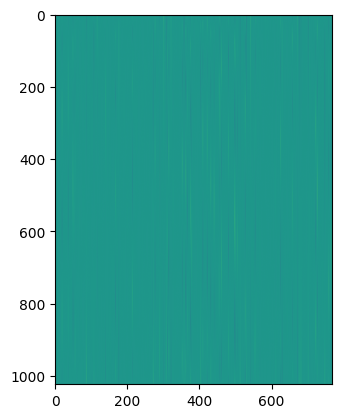

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
# positional encoding for the first token
plt.imshow(sd_hf['transformer.wpe.weight'])
plt.show()

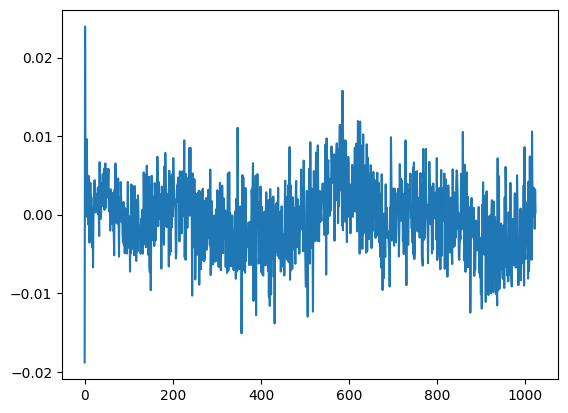

In [18]:
# positional encoding for the first token
plt.plot(sd_hf['transformer.wpe.weight'][:, 0])
plt.show()

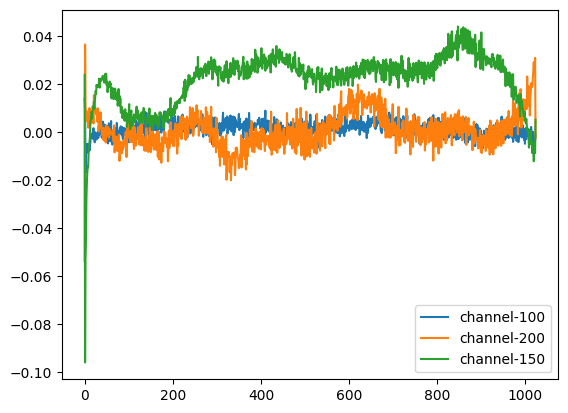

In [19]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 100], label='channel-100')
plt.plot(sd_hf['transformer.wpe.weight'][:, 200], label='channel-200')
plt.plot(sd_hf['transformer.wpe.weight'][:, 250], label='channel-150')
plt.legend()
plt.show()

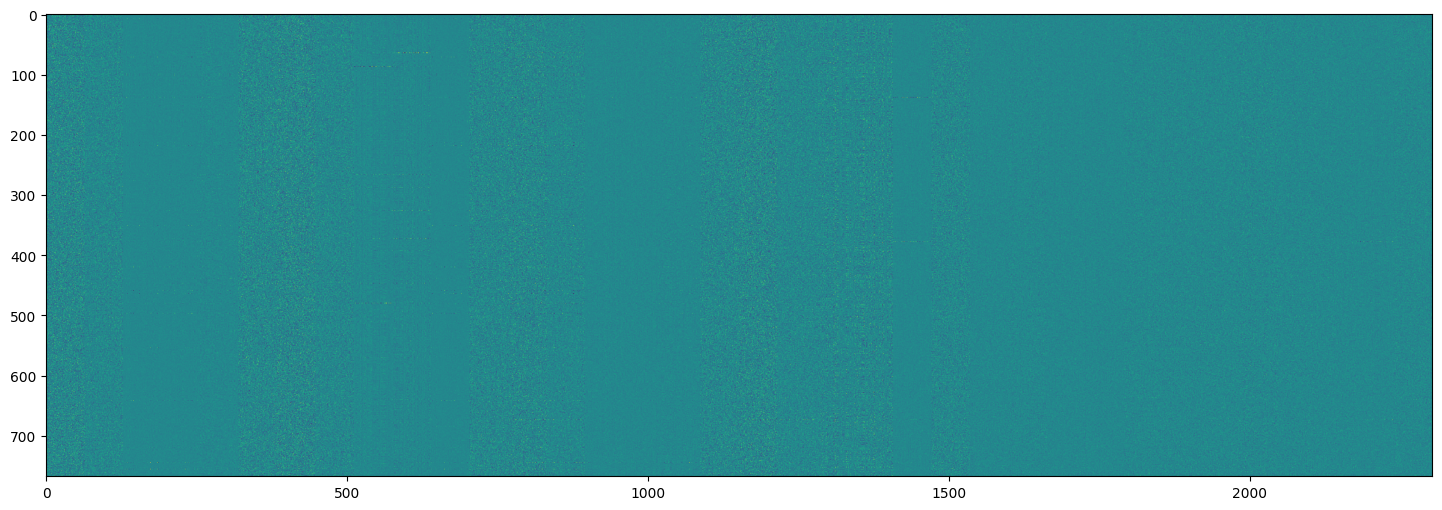

In [20]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"])
plt.show()

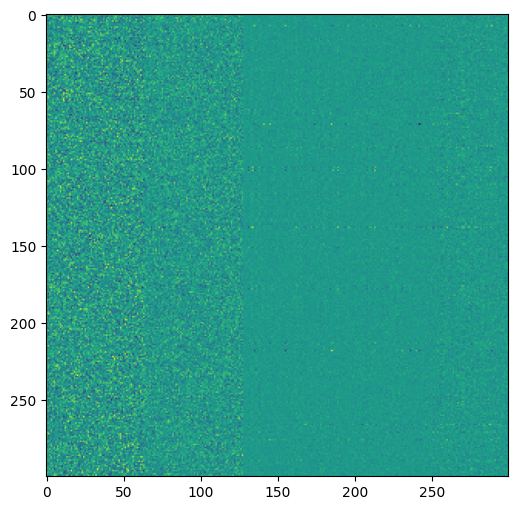

In [21]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300])
plt.show()

**generating sentence from GPT-2 model.**

In [22]:
from transformers import AutoModel
from transformers import pipeline, set_seed

set_seed(17)
# 1. Just load the pipeline. It will handle loading the model & tokenizer automatically.
generator = pipeline('text-generation', model='gpt2')
# 2. Pass the RAW string to the generator.
output = generator(
    "I love Fudan,", 
    max_new_tokens=50,    # How many words to add
    truncation=True,      # Cleanly handle long inputs
    pad_token_id=50256    # Stops the "Setting pad_token_id" warning
)
for i, o in enumerate(output):
    print(f"[{i}] {o['generated_text']}")

Device set to use cuda:0


[0] I love Fudan, and when I see it in the UK, I don't think I've seen a better restaurant."

He says one of the reasons his son's favourite place is Fudan is because of the food and the atmosphere.

"When


GPT-2 architecture:

- GPT class ([nn.ModuleDict](https://pytorch.org/docs/stable/generated/torch.nn.ModuleDict.html), [nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [nn.ModuleList](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html), [nn.LayerNorm](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html))
- Block class (CausalSelfAttention, LayerNorm, MLP)
- CausalSelfAttention class (Dropout, nn.Linear)
- MLP class (nn.Linear, nn.GELU, nn.Dropout)

**Please check GPT-2 v1 code**

### 3.2 Load GPT-2 from source code

In [23]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

In [24]:
class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

In [25]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # This line creates a lower triangular attention mask (often called a causal mask) 
        # and registers it as a buffer inside your PyTorch model (not as a parameter).
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

In [26]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [27]:
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

model= GPT.from_pretrained('gpt2')
print('Successfully load the model from GPT-2 to ours!')

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True
Successfully load the model from GPT-2 to ours!


### 3.3 Sampling from GTP-2 initial

- Adding forward for GPT class
- Add tiktoken for tokenization
- Top-k sampling algorithm

In [28]:
from transformers import GPT2LMHeadModel
# Choose your model_type, e.g., 'gpt2'
model_type = 'gpt2' 
model_hf = GPT2LMHeadModel.from_pretrained(model_type)
model_hf.save_pretrained(f"./{model_type}_weights")

In [29]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(f"./{model_type}_weights")
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [30]:
num_return_sequences = 5
max_length = 30
model = GPT.from_pretrained('gpt2')
model.eval()
model.to('cuda')

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [39]:
from transformers import GPT2Tokenizer
# Point it to your local directory
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'm a language model,")
print(tokens)
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens.to('cuda')


[15496, 11, 314, 1101, 257, 3303, 2746, 11]


In [42]:
import math 
# generate! right now x is (B, T) where B = 5, T = 8
# set the seed to 42
device = 'cuda'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
        print(x.shape)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)

30 30
> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not
> Hello, I'm a language model, and one of the reasons I love studying languages, to think that it can be a lot easier for those who
> Hello, I'm a language model, and I wrote it off on the grounds that a language model would make me more fluent. But I'm not
> Hello, I'm a language model, I really like languages. I like languages because like, they're good. And the way we talk about languages
> Hello, I'm a language model, a language model I'm using for data modelling. All I did was test the results and then I wrote some


### 3.4 Sampling from random model

- We only need to change the code code from

```python
  model = GPT.from_pretrained('gpt2')
```
into
```python
  model = GPT(GPTConfig())
```

In [47]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cuda')
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")

tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to('cuda')  # change to GPU, if you have any.

device = 'cuda'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)


9 30
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0062, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0056, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0064, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0057, device='cuda:0')
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061, device='cuda:0')
torch.Size([5, 50257

## 4. Train GPT-2 model using Shakespeare dataset

In [50]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[:200]
print(data)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [52]:
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode(data)
print(tokens[:24])
buf = torch.tensor(tokens[:24])
x = buf.view(4, 6)
print(x)

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]
tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])


In [53]:
# data sample x and label y
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


### 4.1 Form a batch and put it into GPT-2 and then output logits

In [66]:
import math
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to(device)

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to(device)

print(f"using device: {device}")
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
x = buf[:-1].view(B, T).to(device)  # ← move to device
y = buf[1:].view(B, T).to(device)   # ← move to device
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

using device: cuda
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(11.0165, device='cuda:0', grad_fn=<NllLossBackward0>)


**get loss**

In [67]:
import numpy as np
print(np.log(1/50257.))

-10.82490511970208


### 4.2 Training the model via AdamW single batch

In [68]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cuda')

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens.to('cuda')

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
device = "cuda" # OVERRIDE
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
buf = buf.to(device)
x = buf[:-1].view(B, T)
y = buf[1:].view(B, T)
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_hist = []
for i in range(50):
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    loss_hist.append(loss.item())

using device: cuda
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(10.9535, device='cuda:0', grad_fn=<NllLossBackward0>)
step 0, loss: 10.963836669921875
step 1, loss: 6.609742641448975
step 2, loss: 4.373823165893555
step 3, loss: 2.6924431324005127
step 4, loss: 1.5551801919937134
step 5, loss: 0.8588653802871704
step 6, loss: 0.4792371690273285
step 7, loss: 0.2741761803627014
step 8, loss: 0.18159201741218567
step 9, loss: 0.12009397894144058
step 10, loss: 0.0821833685040474
step 11, loss: 0.05904301628470421
step 12, loss: 0.04565078392624855
step 13, loss: 0.036020174622535706
step 14, loss: 0.02968127466738224
step 15, loss: 0.025824841111898422
step 16, loss: 0.022813808172941208
step 17, loss: 0.019975822418928146
step 18, loss: 0.017516108229756355
step 19, loss: 0.015569174662232399
step 20, loss: 0.01397319883108139
step 21, loss: 0.01256348192691803
step 22, loss: 0.011305928230285645
step 23, loss: 0.010204125195741653
step 24, loss: 0.00925366394221782

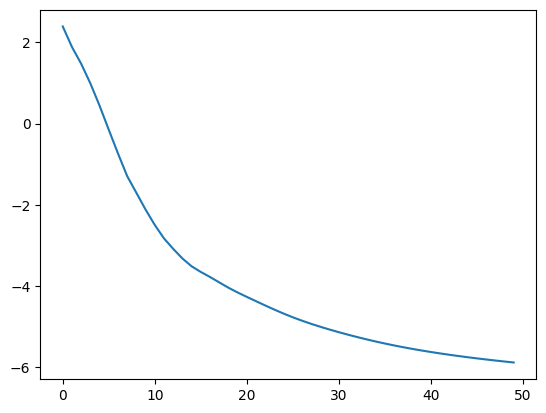

In [69]:
plt.plot(np.log(loss_hist))
plt.show()

**The model is overfitting the single batch!**

### 4.3 Embedding and Unembedding sharing

In [58]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [59]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [60]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

140626553720787
140626553720787


**[https://github.com/openai/gpt-2/blob/master/src/model.py embedding model line 154](https://github.com/openai/gpt-2/blob/master/src/model.py)**

**[https://github.com/openai/gpt-2/blob/master/src/model.py unembedding model line 171](https://github.com/openai/gpt-2/blob/master/src/model.py)**

In [72]:
from dataclasses import dataclass
import torch
import math
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T
        # at init load tokens from disk and store them in memory
        with open('input.txt', 'r') as f:
            text = f.read()
        tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
        tokens = tokenizer.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B * T)} batches")
        # state
        self.current_position = 0
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T
        # if loading the next batch would be out of bounds, reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)


    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

train_loader = DataLoaderLite(B=4, T=32)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
hist_loss = []
for i in range(800):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)  # ← add this line
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    hist_loss.append(loss.item())

using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 11.000391006469727
step 1, loss: 9.727559089660645
step 2, loss: 8.944099426269531
step 3, loss: 9.238123893737793
step 4, loss: 8.772274017333984
step 5, loss: 8.335683822631836
step 6, loss: 8.979511260986328
step 7, loss: 8.854665756225586
step 8, loss: 8.158709526062012
step 9, loss: 7.950156211853027
step 10, loss: 8.40519905090332
step 11, loss: 7.398210048675537
step 12, loss: 7.759417533874512
step 13, loss: 7.480447769165039
step 14, loss: 7.57634162902832
step 15, loss: 7.453908920288086
step 16, loss: 7.492216110229492
step 17, loss: 8.339941024780273
step 18, loss: 7.251832962036133
step 19, loss: 7.84147310256958
step 20, loss: 7.538625240325928
step 21, loss: 7.79096794128418
step 22, loss: 6.476423263549805
step 23, loss: 6.8955979347229
step 24, loss: 6.805852890014648
step 25, loss: 6.584911823272705
step 26, loss: 6.6011962890625
step 27, loss: 7.5112152099609375
step 28, loss: 7.003516674041

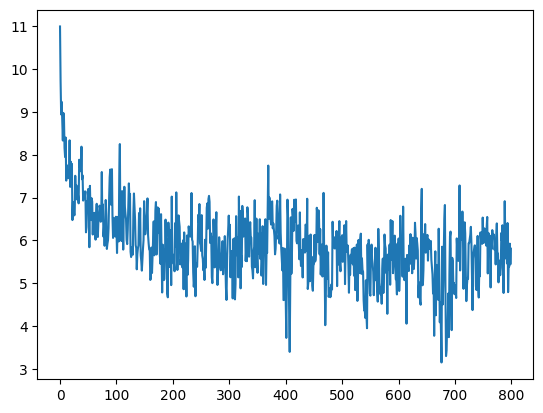

In [73]:
plt.plot(hist_loss)
plt.show()

In [76]:
!time python train_gpt2_multi_epoch.py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/inspire/hdd/project/fdu-aidake-cfff/public/baojian/llm-26/lecture-06-gpts/.venv/lib/python3.14/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
torch.compile skipped: not supported on Python 3.14+
step 0, loss: 10.983463287353516
step 1, loss: 9.763798713684082
step 2, loss: 8.92474365234375
step 3, loss: 9.161955833435059
step 4, loss: 8.900724411010742
step 5, loss: 8.385331153869629
step 6, loss: 9.02802848815918
step 7, loss: 8.77871322631836
step 8, loss: 8.032678604125977
step 9, loss: 7.972997188568115
step 10, loss: 8.292680740356445
step 11, loss: 7.539348602294922
step 12, loss: 7.8118462562561035
step 13, loss: 7.402791976928711
step 14, loss: 7.519497394561768
step 15, loss: 7.359035015106201
step 16, loss: 7.41779899597168
step 17, loss: 8.208930969238281
step 18, loss: 7.23384

### 4.4 FlashAttention

**To speedup the multi head attention, one can apply [flash attention](https://arxiv.org/abs/2205.14135).**

In [78]:
!time python train_gpt2_flash_attention.py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/inspire/hdd/project/fdu-aidake-cfff/public/baojian/llm-26/lecture-06-gpts/.venv/lib/python3.14/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
using device: cuda
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 10.888607025146484
step 1, loss: 9.663393020629883
step 2, loss: 9.190193176269531
step 3, loss: 9.148200988769531
step 4, loss: 8.587461471557617
step 5, loss: 8.406128883361816
step 6, loss: 9.052865028381348
step 7, loss: 8.710504531860352
step 8, loss: 8.133942604064941
step 9, loss: 7.980304718017578
step 10, loss: 8.287149429321289
step 11, loss: 7.433160781860352
step 12, loss: 7.795192718505859
step 13, loss: 7.391221046447754
step 14, loss: 7.50350284576416
step 15, loss: 7.323759078979492
step 16, loss: 7.42950439453125
step 17, loss: 8.270835876464844
step 18, loss: 7.234297752380371
step 19, loss: 7.728084564208984
step 20,

### 4.5 Learning rate Schedule

In [79]:
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
        return max_lr * (it+1) / warmup_steps
    # 2) if it > lr_decay_iters, return min learning rate
    if it > max_steps:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

## 5. Train GPT-2 using fineweb-edu dataset

- We will use [https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) for training a GPT-2 model.
- Paper [The FineWeb Datasets: Decanting the Web for the Finest Text Data at Scale](https://arxiv.org/pdf/2406.17557)
- **sample-10BT**: a subset randomly sampled from the whole dataset of around 10B gpt2 tokens

### 5.1 Cannot login huggingface?

Try the following shell variable:

```shell
export HF_ENDPOINT="https://hf-mirror.com"
```

Then run the following command:

```shell
python fineweb.py
```

### 5.2 Training GPT-2 on GPU

Then run the following command:

```shell
python fineweb.py
```

If the B=64 (batch size is too large, just let it be 32 or 16).

### 5.3 Evaluation on [HellaSWAG](https://arxiv.org/abs/1905.07830)

Run the following command:

```python
python hellaswag.py
```